## 2 - Modelo LSTM Base

**Entrada**: `data/processed/features_all.parquet` + `cohort_all.parquet` (NB1)  
**Objetivo**: Entrenar un LSTM base para clasificación binaria sepsis / no-sepsis.  
**Secuencias**: 48 timesteps × 16 features | ventana [-48h, 0) respecto al ingreso UCI.

---
**Pipeline**:
1. Cargar datos combinados (sepsis + control)
2. Construir tensor 3D + imputación + normalización
3. Split train/val/test **por paciente** (sin data leakage)
4. LSTM Baseline — entrenamiento + evaluación (AUROC, AUPRC)

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    roc_curve, precision_recall_curve
)
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
import json
import pickle

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

print(f'PyTorch: {torch.__version__}')
print(f'CUDA disponible: {torch.cuda.is_available()}')

PyTorch: 2.11.0+cu130
CUDA disponible: True


In [2]:
BASE_DATA_DIR = '../data'
OUTPUT_DIR    = '../data/processed'
MODELS_DIR    = '../models'
RESULTS_DIR   = '../results'

HOURS_BEFORE  = 48 # Horas previas al ingreso en UCI
MIN_HOURS     = 6 # Estancias con al menos N horas de datos
N_CONTROLS    = 29_966  # Controles (ratio 1:1 con sepsis)

# Hiperparámetros
BATCH_SIZE    = 64
EPOCHS        = 50
LR            = 1e-3 # 0.001
WEIGHT_DECAY  = 1e-5 # 0.00001
PATIENCE      = 7 # Numero de etapas hasta parar el entrenamiento en EarlyStopping
# EL LSTM mantiene en cada timestep un vector de estado oculto, con este valor definimos la dimension de la "memoria de trabajo"
# En este caso la capa LSTM recibe 32 features por timestep, y produce un vector de 128 valores en cada paso temporal
HIDDEN_SIZE   = 128 # entrada: (batch, 48, 32) -> LSTM -> (batch, 48, 128) 128 neuronas ocultas
NUM_LAYERS    = 2
DROPOUT       = 0.5

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')

Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)
Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)
# ─────────────────────────────────────────────────────────────────────────────

Dispositivo: cuda


El primer paso es cargar los datos preprocesados en el primer notebook.

In [3]:
features_all = pd.read_parquet(f'{OUTPUT_DIR}/features_all.parquet')
cohort_all   = pd.read_parquet(f'{OUTPUT_DIR}/cohort_all.parquet')

# Temperature Celsius: 99.8% nulos en NB1 → eliminada
FEATURE_COLS = [
    c for c in features_all.columns
    if c not in ['stay_id', 'hour_bucket', 'Temperature Celsius']
]
N_FEATURES = len(FEATURE_COLS)

print(f'Estancias totales: {cohort_all["stay_id"].nunique():,}')
print(f'  Sepsis  (label=1): {(cohort_all["label"]==1).sum():,}')
print(f'  Control (label=0): {(cohort_all["label"]==0).sum():,}')
print(f'Features ({N_FEATURES}): {FEATURE_COLS}')

Estancias totales: 59,932
  Sepsis  (label=1): 29,966
  Control (label=0): 29,966
Features (16): ['Arterial Blood Pressure mean', 'GCS - Motor Response', 'GCS - Verbal Response', 'Heart Rate', 'Non Invasive Blood Pressure diastolic', 'Non Invasive Blood Pressure systolic', 'O2 saturation pulseoxymetry', 'PEEP set', 'Respiratory Rate', 'Bilirubin, Total', 'Creatinine', 'Lactate', 'Platelet Count', 'Urea Nitrogen', 'pH', 'pO2']


El siguiente paso es separar los datos, la estrategia es separar por 60/20/20 usando el protocolo ***GroupShuffleSplit***. Esto se debe a que es posible que los datos de una estancia esten separados en los diferentes conjuntos de entrenamiento, validación y test. Al aplicar esta estrategia, agrupamos los datos y evitamos Data Leakage.

In [4]:
# Agrupamos los datos por estancia y contamos las secuencias horarias que tenemos (cuantas horas tiene cada estancia)
stays_coverage = features_all.groupby('stay_id')['hour_bucket'].count()
# Filtramos por el minimo de horas establecido previamente y obtenemos una lista de identificadores
valid_stay_ids = stays_coverage[stays_coverage >= MIN_HOURS].index

# Extraemos etiquetas y pacientes a partir de las estancias filtradas
stay_labels_v = cohort_all[cohort_all['stay_id'].isin(valid_stay_ids)][
    ['stay_id', 'label', 'subject_id']
].reset_index(drop=True)

# Obtenemos listas para poder usar GroupShuffleSplit
all_stays = stay_labels_v['stay_id'].values # Lista de identificadores de estancias
all_labels = stay_labels_v['label'].values # Sepsis o control (sepsis / no sepsis) [0, 1, 1, 0...]
all_subjects = stay_labels_v['subject_id'].values # Lista de identificadores de pacientes

# Split 1: train + val (80%) / test (20%)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
tv_idx, test_idx = next(gss1.split(all_stays, all_labels, groups=all_subjects))

# Split 2: train (75%) / val (25%) del 80% anterior → 60/20/20 global
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
tr_idx, val_idx = next(gss2.split(
    all_stays[tv_idx], all_labels[tv_idx], groups=all_subjects[tv_idx]
))

# Extraemos los identificadores de estancia
train_stays = all_stays[tv_idx][tr_idx] # 80% → 75% de ese 80% = 60% global
val_stays = all_stays[tv_idx][val_idx] # 80% → 25% de ese 80% = 20% global
test_stays = all_stays[test_idx] # 20% global

# Creamos un mapa de estancia → paciente y se usa para obtener que pacientes hay en cada conjunto.
s2sub = cohort_all.set_index('stay_id')['subject_id']
tr_sub = set(s2sub[s2sub.index.isin(train_stays)]) # pacientes en train
va_sub = set(s2sub[s2sub.index.isin(val_stays)]) # pacientes en val
te_sub = set(s2sub[s2sub.index.isin(test_stays)]) # pacientes en test

print(f'Train: {len(train_stays):,} estancias | {len(tr_sub):,} pacientes')
print(f'Val: {len(val_stays):,} estancias | {len(va_sub):,} pacientes')
print(f'Test: {len(test_stays):,} estancias | {len(te_sub):,} pacientes')

Train: 2,193 estancias | 2,004 pacientes
Val: 732 estancias | 668 pacientes
Test: 736 estancias | 669 pacientes


El siguiente paso es construir los tensores.
Definimos una funcion que permita construir un tensor de la misma forma en base a unos parametros.

In [5]:
def build_tensor(features_df, stay_ids, feature_cols, hours=HOURS_BEFORE):
    """Convierte features_df en tensor numpy (n, hours, n_features)."""

    stay_ids = list(stay_ids) # Lista de identificadores de estancias

    n = len(stay_ids) # Numero de estancias
    F = len(feature_cols) # Numero de variables
    X = np.full((n, hours, F), np.nan, dtype=np.float32) # Matriz rellena con NaN con forma (estancias, 48 horas, N variables)
    
    # Asignamos a cada estancia su posicion en la matriz
    id_to_idx = pd.Series(np.arange(n), index=stay_ids) # Secuencia de posiciones, establecemos como indice el identificador de estancia
    col_to_idx = {c: j for j, c in enumerate(feature_cols)} # Crea una secuencia de posiciones para las variables

    # Filtramos solo las filas relevantes (solo las secuencias dentro de la ventana de 48h)
    df = features_df[
        features_df['stay_id'].isin(set(stay_ids)) &
        features_df['hour_bucket'].between(-hours, -1)
    ].copy()
    
    df['_i'] = id_to_idx[df['stay_id'].values].values # Añadir la posición de cada estancia en la matriz
    
    # Convertir hour_bucket de negativo a positivo: -48 → 0, -1 → 47
    # para que sirva como índice directo en el eje temporal del cubo
    df['_t'] = (df['hour_bucket'] + hours).astype(int)

    df = df.dropna(subset=['_i']) # Eliminamos filas cuyo stay_id no tiene posición asignada (no deberían existir)

    # Rellenar la matriz variable a variable
    for col, j in col_to_idx.items():
        if col not in df.columns: # Saltar si la variable no está en los datos
            continue
        
        # Extraemos solo las filas sin valores nulos
        sub = df[['_i', '_t', col]].dropna(subset=[col])

        i_idx = sub['_i'].astype(int).values # Índice de estancia
        t_idx = sub['_t'].astype(int).values # Índice de hora
        vals = sub[col].values.astype(np.float32) # Valor clínico
        
        # Filtro de seguridad: descartar índices fuera del rango válido [0, 47]
        mask = (t_idx >= 0) & (t_idx < hours)

        # Colocar cada valor en su celda exacta de la matriz [estancia, hora, variable]
        X[i_idx[mask], t_idx[mask], j] = vals[mask]

    return X

# Construir un tensor para cada conjunto (entrenamiento, validacion y test)
X_train_raw = build_tensor(features_all, train_stays, FEATURE_COLS)
X_val_raw = build_tensor(features_all, val_stays, FEATURE_COLS)
X_test_raw = build_tensor(features_all, test_stays, FEATURE_COLS)

# Extraemos las etiquetas (0/1) para cada conjunto usando el stay_id como identificador
label_map = stay_labels_v.set_index('stay_id')['label']
y_train = label_map[train_stays].values.astype(np.float32)
y_val = label_map[val_stays].values.astype(np.float32)
y_test = label_map[test_stays].values.astype(np.float32)

print(f'X_train: {X_train_raw.shape} | positivos: {y_train.mean():.2%}')
print(f'X_val: {X_val_raw.shape} | positivos: {y_val.mean():.2%}')
print(f'X_test: {X_test_raw.shape} | positivos: {y_test.mean():.2%}')

X_train: (2193, 48, 16) | positivos: 59.74%
X_val: (732, 48, 16) | positivos: 62.70%
X_test: (736, 48, 16) | positivos: 58.42%


Es necesario aplicar una estrategia para imputar datos en las estancias donde no tenemos un total de 48 secuencias, este requisito es obligatorio para poder definir el modelo LSTM, para cumplir este objetivo se aplica Missingness Mask + Normalización.

1. Rellenamos las secuencias nulas con la mediana global
2. Aplicamos máscara binaria, definimos ccomo 1 en caso de ser una medicion real, 0 si es un valor imputado.
3. Concatenamos las mediciones + máscara

In [6]:
def apply_missingness_mask(X, train_medians=None):
    """
    Estrategia de imputación con missingness mask:
    1. Construye máscara binaria M: 1 = valor real, 0 = imputado.
    2. Rellena NaN con la mediana global del training (valor neutro).
    3. Concatena [X_imputed | M] → shape (n, T, 2*F).
    La máscara preserva la señal de ausencia como feature explícito.
    """

    _, _, F = X.shape

    # Creamos máscara binaria: 1 donde había un dato real, 0 donde había NaN
    M = (~np.isnan(X)).astype(np.float32)

    X_imp = X.copy()

    # Si no se pasan medianas (solo ocurre en train), calcularlas desde los datos
    if train_medians is None:
        flat = X_imp.reshape(-1, F) # Aplanar a 2D para calcular mediana por variable
        train_medians = np.nanmedian(flat, axis=0) # Mediana de cada variable ignorando NaN
        train_medians = np.where(np.isnan(train_medians), 0.0, train_medians) # Sustituir NaN residuales por 0

    # Rellenar los NaN de cada variable con su mediana del training
    for j in range(F):
        mask_nan = np.isnan(X_imp[:, :, j]) # Localizar celdas vacías de la variable j
        X_imp[:, :, j][mask_nan] = train_medians[j]  # Rellenar con la mediana

    # Concatenar valores imputados y máscara → el LSTM recibe 32 variables en lugar de 16
    X_out = np.concatenate([X_imp, M], axis=2).astype(np.float32)
    return X_out, train_medians

# En train se calculan las medianas; en val y test se reutilizan las de train
X_train_masked, train_medians = apply_missingness_mask(X_train_raw)
X_val_masked,  _ = apply_missingness_mask(X_val_raw, train_medians)
X_test_masked, _ = apply_missingness_mask(X_test_raw, train_medians)

F = len(FEATURE_COLS)
# Calcular qué proporción de celdas tenían un dato real (las máscaras son 1 donde había dato)
real_ratio = X_train_masked[:, :, F:].mean()
print(f'Shape tras aplicar mask: {X_train_masked.shape} → input_size al LSTM: {X_train_masked.shape[2]}')

Shape tras aplicar mask: (2193, 48, 32) → input_size al LSTM: 32


In [7]:
# Solo se normalizan los 16 valores clínicos — las 16 máscaras ya son binarias {0,1} y no deben normalizarse
n_tr, T, F2 = X_train_masked.shape
F = F2 // 2  # Los primeros 16 canales son valores, los últimos 16 son máscaras

scaler = StandardScaler()  # Normalización z-score: media 0, desviación estándar 1

def scale_masked(X, scaler, F, fit=False):
    n, T, _ = X.shape
    X_vals = X[:, :, :F].reshape(-1, F)  # Extraer las 16 variables
    X_mask = X[:, :, F:] # Separar las 16 máscaras

    if fit:
        # En train: calcular media y desviación estándar y aplicar la normalización
        X_vals_scaled = scaler.fit_transform(X_vals)
    else:
        # En val y test: aplicar la normalización con los parámetros calculados en train
        # (evita data leakage: val/test no influyen en el cálculo de la normalización)
        X_vals_scaled = scaler.transform(X_vals)

    X_vals_scaled = X_vals_scaled.reshape(n, T, F).astype(np.float32)  # Restaurar forma 3D

    # Volver a concatenar valores normalizados con las máscaras sin tocar
    return np.concatenate([X_vals_scaled, X_mask], axis=2).astype(np.float32)

# Aplicar normalización: fit solo en train, transform en val y test
X_train_norm = scale_masked(X_train_masked, scaler, F, fit=True)
X_val_norm   = scale_masked(X_val_masked,   scaler, F, fit=False)
X_test_norm  = scale_masked(X_test_masked,  scaler, F, fit=False)

N_INPUT = X_train_norm.shape[2]  # 32 = 16 valores normalizados + 16 máscaras binarias
print(f'Input final al LSTM: {N_INPUT}  (shape: {X_train_norm.shape})')
print(f'Máscaras — rango: [{X_train_norm[:,:,F:].min():.0f}, {X_train_norm[:,:,F:].max():.0f}]')

Input final al LSTM: 32  (shape: (2193, 48, 32))
Máscaras — rango: [0, 1]


A continuación, definimos un objeto para poder leer los datos con la librería PyTorch, esta nueva clase va a alimentar el modelo durante el entrenamiento. Preparamos cada conjunto usando la clase definida. A continuación, se dividen los datos en batches y se mezcla el orden para evitar que el modelo memorize al entrenar por épocas.

In [8]:
class SepsisDataset(Dataset):
    """Clase que alimenta al modelo durante el entrenamiento"""
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()  # Convertir array numpy a tensor de PyTorch
        self.y = torch.from_numpy(y).float()  # Convertir etiquetas a tensor de PyTorch

    def __len__(self):
        return len(self.y) # Devuelve el número total de estancias

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]  # Devuelve una estancia y su etiqueta por índice


# Crear datasets para cada conjunto
train_ds = SepsisDataset(X_train_norm, y_train)
val_ds = SepsisDataset(X_val_norm,   y_val)
test_ds = SepsisDataset(X_test_norm,  y_test)

# DataLoader: divide los datos en batches y los sirve al modelo durante el entrenamiento
# shuffle=True en train: mezcla el orden en cada época para evitar que el modelo memorice el orden
# drop_last=True en train: descarta el último batch si tiene menos de BATCH_SIZE muestras
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)  # Sin mezcla en evaluación
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)  # Sin mezcla en evaluación

# Calcular el peso de la clase positiva para la función de pérdida
# Como hay balance 1:1, pos_weight ≈ 1 — si hubiera desbalanceo daría más peso a la clase minoritaria
n_pos = int(y_train.sum()) # Número de casos de sepsis en train
n_neg = len(y_train) - n_pos # Número de controles en train
pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32).to(DEVICE)

print(f'Train batches: {len(train_loader)} × {BATCH_SIZE}')
print(f'pos_weight: {pos_weight.item():.3f} (n_neg={n_neg} / n_pos={n_pos})')

Train batches: 34 × 64
pos_weight: 0.674 (n_neg=883 / n_pos=1310)


El siguiente paso es definir el modelo que ejecuta clasificación binaria para detectar si un paciente tiene sepsis o no. Definimos un modelo que permite definir el tamaño de entrada, el tamaño del vector de estado oculto, el número de capas y la tasa de Dropout.
Dentro del modelo LSTM se crea una funcion ***forward*** que define como fluyen los datos dentro del modelo.

----

Recibe una forma (batch, 48, 32) - un batch de estancias, 48 horas y 32 features

El modelo procesa la secuencia completa, manteniendo su estado oculto interno

Devuelve un output con forma (batch, 48, 128) - representa 128 dimensiones para cada hora dentro de la ventana temporal de 48 horas. Se descarta los estados finales ya que no son necesarios.

---

Obtiene el estado del último timestep (hora -1, justo antes de ingresar en UCI) con forma (batch, 128)

Este vector resume toda la secuencia de 48 horas aprendida por el modelo.

Se aplica Dropout y desactiva el 50% de las neuronas de forma aleatoria para reducir overfitting.

---

La capa densa reduce las dimensiones de 128 a 64

Se aplica funcion de activacion mediante ReLU, convierte valores negativos a 0 y introduce no linealidad.

---

Reduce las dimensiones de 64 a 1, obtiene un logit por estancia. (Un logit es la puntuación del modelo cruda, es necesario comprimirlo en un rango interpretable como [0, 1])

Elimina la dimension extra: (batch, 1) -> (batch,)

Este logit se acaba convirtiendo a un rango interpretable de [0, 1] aplicando sigmoid fuera del modelo

In [ ]:
class LSTMBase(nn.Module):
    """Modelo LSTM para clasificación binaria sepsis / no-sepsis."""
    def __init__(self, input_size, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT):
        super().__init__()

        # Capa LSTM: procesa la secuencia de 48 timesteps y aprende dependencias temporales
        # input_size=32 (16 valores + 16 máscaras), hidden_size=128 neuronas por capa
        # num_layers=2: dos capas LSTM apiladas para capturar patrones más complejos
        # batch_first=True: el input tiene forma (batch, seq_len, features) en lugar de (seq_len, batch, features)
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0  # Dropout entre capas LSTM (no en la última)
        )

        # Dropout: desactiva neuronas aleatoriamente durante el entrenamiento para evitar overfitting
        self.dropout = nn.Dropout(dropout)

        # Capa densa: reduce las 128 neuronas del LSTM a 64
        self.fc1 = nn.Linear(hidden_size, 64)

        # Función de activación ReLU: introduce no linealidad para aprender patrones complejos
        self.relu = nn.ReLU()

        # Capa de salida: reduce a 1 neurona que representa la probabilidad de sepsis
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        # x tiene forma (batch, 48, 32): batch de estancias, 48 horas, 32 features

        # Pasar la secuencia completa por el LSTM
        out, _ = self.lstm(x)

        # Toma solo el estado del último timestep (hora -1, justo antes del ingreso UCI)
        # ya que resume toda la información de la secuencia de 48h
        out = self.dropout(out[:, -1, :])

        # Pasar por las capas densas para obtener la predicción final
        out = self.relu(self.fc1(out))

        # squeeze(-1): elimina la dimensión extra → devuelve un escalar por estancia (logit)
        return self.fc2(out).squeeze(-1)


# Instancia el modelo y moverlo al dispositivo (GPU si está disponible)
model = LSTMBase(input_size=N_INPUT).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())  # Contar parámetros entrenables
print(f'Input size: {N_INPUT}  (16 valores + 16 máscaras)')
print(f'Parámetros: {total_params:,}')
print(model)

Input size: 32  (16 valores + 16 máscaras)
Parámetros: 223,361
LSTMBase(
  (lstm): LSTM(32, 128, num_layers=2, batch_first=True, dropout=0.5)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


A continuación se definen la función de pérdida, el optimizador, el scheduler y se aplica el entrenamiento por épocas en base a la configuración.

In [ ]:
# Función de pérdida: Binary Cross-Entropy con logits
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimizador Adam: ajusta los pesos del modelo en cada paso usando el gradiente
# lr=tasa de aprendizaje, weight_decay=regularización L2 para evitar overfitting
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Scheduler: reduce la tasa de aprendizaje a la mitad si la pérdida de validación
# no mejora durante 3 épocas consecutivas — permite afinar el modelo en etapas tardías
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

# Historial de métricas por época para graficar las curvas de entrenamiento
history          = {'train_loss': [], 'val_loss': [], 'val_auroc': []}
best_val_loss    = float('inf')  # Mejor pérdida de validación vista hasta ahora
patience_counter = 0             # Contador de épocas sin mejora para early stopping
best_path        = f'{MODELS_DIR}/lstm_baseline_best.pt'  # Ruta donde guardar el mejor modelo

# Entrenamiento por épocas, se define el numero de épocas previamente (50)
for epoch in range(1, EPOCHS + 1):

    # Fase de entrenamiento
    model.train()  # Activar modo entrenamiento (dropout activo)
    train_loss    = 0.0
    train_samples = 0

    """
    Toma los features y objetivo de los datos de entrenamiento
    Por cada fila se aplica todo el proceso de:
    Limpiar gradientes -> Calcular pérdida -> Calcular gradientes -> Recortar gradientes -> Actualizar pesos del modelo -> Acumular pérdida ponderada -> Acumular número de muestras procesadas
    """
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)  # Mover batch a GPU/CPU
        optimizer.zero_grad() # Limpiamos gradientes del paso anterior
        loss = criterion(model(X_b), y_b) # Calculamos pérdida del batch
        loss.backward() # Calculamos gradientes (backpropagation)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Recortar gradientes para estabilidad
        optimizer.step() # Actualizamos pesos del modelo
        train_loss    += loss.item() * len(y_b) # Acumular pérdida ponderada por tamaño de batch
        train_samples += len(y_b) # Acumular número de muestras procesadas

    train_loss /= train_samples # Pérdida media real

    # Fase de validación
    model.eval()  # Activar modo evaluación (dropout desactivado)
    val_loss  = 0.0
    val_probs, val_true = [], []

    with torch.no_grad():  # Desactivar cálculo de gradientes para ahorrar memoria
        """
        1. Toma los features y objetivo de los datos de validación
        2. Convierte logits a probabilidades [0, 1] y las acumula
        3. Acumula las etiquetas reales (1 = sepsis, 0 = control)
        """
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            logits = model(X_b)
            val_loss += criterion(logits, y_b).item() * len(y_b)
            val_probs.extend(torch.sigmoid(logits).cpu().numpy())  # Convertir logits a probabilidades [0,1]
            val_true.extend(y_b.cpu().numpy())

    # Pérdida media por estancia sobre todo el conjunto de validación
    val_loss /= len(val_ds)
    # Calculamos AUROC de validación solo si hay ambas clases presentes
    val_auroc = roc_auc_score(val_true, val_probs) if len(set(val_true)) > 1 else 0.0

    # Guardamos métricas de la época en el historial
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auroc'].append(val_auroc)

    # Ajustamos tasa de aprendizaje si la pérdida de validación no mejora
    scheduler.step(val_loss)

    if epoch % 5 == 0 or epoch == 1:
        lr_current = optimizer.param_groups[0]['lr']  # Tasa de aprendizaje actual
        print(f'Epoch {epoch:3d}/{EPOCHS}  '
              f'Train Loss: {train_loss:.4f}  '
              f'Val Loss: {val_loss:.4f}  '
              f'Val AUROC: {val_auroc:.4f}  '
              f'LR: {lr_current:.2e}')

    # Early stopping: guardar el modelo si mejora, o aumentar el contador si no
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_path)  # Guardar los pesos del mejor modelo
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:  # Detener si llevamos PATIENCE épocas sin mejorar
            print(f'Early stopping en epoch {epoch}')
            break

print(f'\nMejor val_loss: {best_val_loss:.4f}')

Epoch   1/50  Train Loss: 0.5405  Val Loss: 0.5347  Val AUROC: 0.6567  LR: 1.00e-03
Epoch   5/50  Train Loss: 0.4838  Val Loss: 0.4921  Val AUROC: 0.6912  LR: 1.00e-03
Epoch  10/50  Train Loss: 0.4652  Val Loss: 0.5083  Val AUROC: 0.7074  LR: 1.00e-03
Epoch  15/50  Train Loss: 0.4290  Val Loss: 0.5297  Val AUROC: 0.7060  LR: 5.00e-04
Early stopping en epoch 15

Mejor val_loss: 0.4902


Mostramos gráficamente la evolución del modelo durante el entrenamiento por épocas.

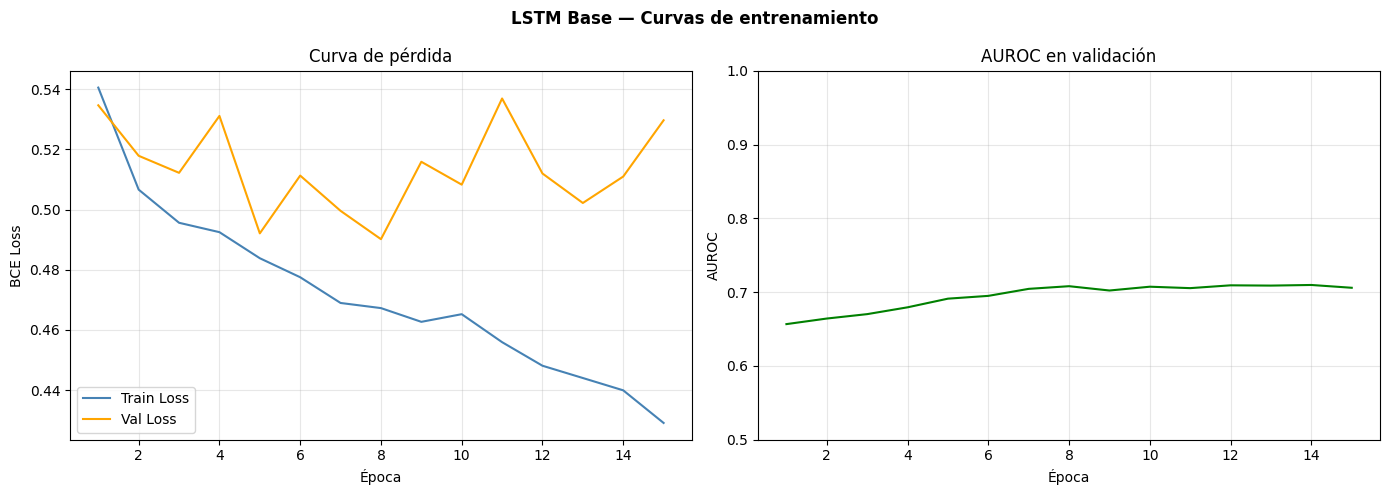

In [15]:
epochs_ran = range(1, len(history['train_loss']) + 1)  # Épocas realmente ejecutadas (puede ser < EPOCHS por early stopping)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico izquierdo: curva de pérdida de train y validación por época
# Si val_loss baja junto con train_loss el modelo está aprendiendo correctamente
# Si val_loss sube mientras train_loss baja hay overfitting
ax1.plot(epochs_ran, history['train_loss'], label='Train Loss', color='steelblue')
ax1.plot(epochs_ran, history['val_loss'],   label='Val Loss',   color='orange')
ax1.set_xlabel('Época')
ax1.set_ylabel('BCE Loss')
ax1.set_title('Curva de pérdida')
ax1.legend()
ax1.grid(alpha=0.3)

# Gráfico derecho: AUROC en validación por época
# Permite ver si el modelo mejora su capacidad discriminativa con el entrenamiento
ax2.plot(epochs_ran, history['val_auroc'], color='green')
ax2.set_xlabel('Época')
ax2.set_ylabel('AUROC')
ax2.set_title('AUROC en validación')
ax2.set_ylim([0.5, 1.0])
ax2.grid(alpha=0.3)

plt.suptitle('LSTM Base — Curvas de entrenamiento', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/lstm_baseline_training.png', dpi=150, bbox_inches='tight')  # Guardar imagen
plt.show()

El gráfico indica que la pérdida de entrenamiento desciende de forma constante, mientras que la pérdida de validación se vuelve errática a partir de la época 5; esto nos indica que el modelo empieza a memorizar el ruido. Este resultado da a entender que el modelo es muy sensible a los datos de validación, lo que puede indicar que el learning rate es elevado o que la regularización aplicada no es suficiente en este dataset.

Otro punto a tener en cuenta es que el AUROC en validación mejora bastante, aunque a partir de la época 8 se estanca y se vuelve plano.

In [16]:
# Cargar los pesos del mejor modelo guardado durante el entrenamiento (menor val_loss)
model.load_state_dict(torch.load(best_path, map_location=DEVICE, weights_only=True))
model.eval() # Activar modo evaluación (dropout desactivado)

test_probs, test_true = [], []
with torch.no_grad(): # Sin cálculo de gradientes: solo inferencia
    for X_b, y_b in test_loader:
        logits = model(X_b.to(DEVICE))                              # Predicción del modelo (logits)
        test_probs.extend(torch.sigmoid(logits).cpu().numpy())      # Convertir a probabilidades [0,1]
        test_true.extend(y_b.numpy())                               # Recoger etiquetas reales

test_probs = np.array(test_probs)               # Lista → array numpy
test_true  = np.array(test_true)                # Lista → array numpy
preds      = (test_probs >= 0.5).astype(int)    # Umbral 0.5: probabilidad >= 0.5 → predice sepsis

# AUROC: probabilidad de que el modelo puntúe más alto un caso real de sepsis que uno de control
auroc = roc_auc_score(test_true, test_probs)

# AUPRC: área bajo la curva precisión-recall, más informativa que AUROC en contextos clínicos
auprc = average_precision_score(test_true, test_probs)

print('=== LSTM Base — Test Set ===')
print(f'AUROC: {auroc:.4f}')
print(f'AUPRC: {auprc:.4f}')
print()
# Desglose de precisión, recall y F1 por clase con umbral 0.5
print(classification_report(test_true, preds, target_names=['Control', 'Sepsis']))

=== LSTM Base — Test Set ===
AUROC: 0.7622
AUPRC: 0.7805

              precision    recall  f1-score   support

     Control       0.71      0.55      0.62       306
      Sepsis       0.72      0.84      0.78       430

    accuracy                           0.72       736
   macro avg       0.72      0.69      0.70       736
weighted avg       0.72      0.72      0.71       736



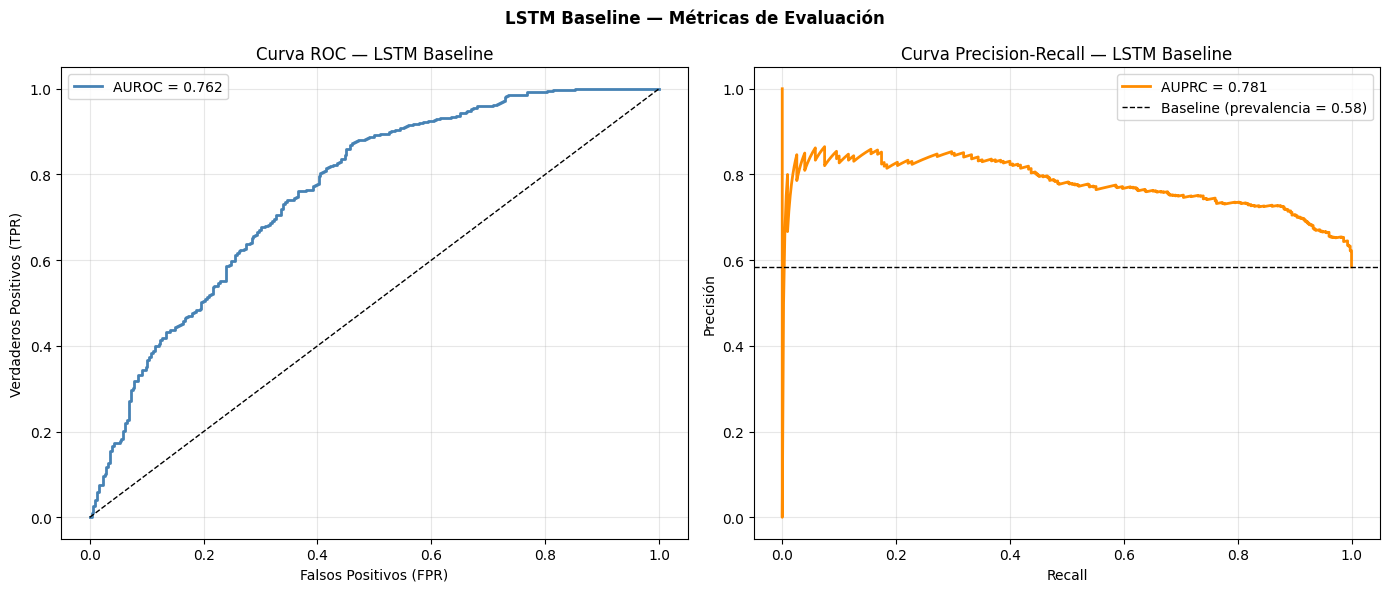

In [ ]:
# Calcular puntos de las curvas ROC y Precision-Recall
fpr, tpr, _ = roc_curve(test_true, test_probs) # Falsos positivos y verdaderos positivos
prec, rec, _ = precision_recall_curve(test_true, test_probs) # Precisión y recall a distintos umbrales

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Curva ROC: muestra el equilibrio entre verdaderos positivos y falsos positivos
# La diagonal punteada representa un clasificador aleatorio (AUROC=0.5)
ax1.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUROC = {auroc:.3f}')
ax1.plot([0, 1], [0, 1], 'k--', lw=1) # Línea de referencia del clasificador aleatorio
ax1.set_xlabel('Falsos Positivos (FPR)')
ax1.set_ylabel('Verdaderos Positivos (TPR)')
ax1.set_title('Curva ROC — LSTM Base')
ax1.legend()
ax1.grid(alpha=0.3)

# Curva Precision-Recall: más informativa que ROC en contextos clínicos
# La línea horizontal es la base de un clasificador que siempre predice la clase positiva
ax2.plot(rec, prec, color='darkorange', lw=2, label=f'AUPRC = {auprc:.3f}')
ax2.axhline(y=test_true.mean(), color='k', ls='--', lw=1, label=f'Base (prevalencia = {test_true.mean():.2f})')  # Proporción de positivos en test
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precisión')
ax2.set_title('Curva Precision-Recall — LSTM Base')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('LSTM Base — Métricas de Evaluación', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/lstm_baseline_curves.png', dpi=150, bbox_inches='tight')  # Guardar imagen
plt.show()

In [18]:
# Guardar el scaler y las medianas de train para reutilizarlos en el NB03
# Es imprescindible usar los mismos parámetros en producción para no introducir data leakage
with open(f'{MODELS_DIR}/scaler_lstm.pkl', 'wb') as f:
    pickle.dump(scaler, f)                                        # Scaler con media y std de train
np.save(f'{MODELS_DIR}/train_medians_lstm.npy', train_medians)   # Medianas usadas en la imputación

# Guardar las métricas y configuración del modelo en JSON para comparar con modelos futuros
results = {
    'model':        'LSTM Base',
    'auroc':        round(float(auroc), 4),        # Métrica principal de discriminación
    'auprc':        round(float(auprc), 4),        # Métrica principal en contexto clínico
    'n_train':      int(len(train_stays)),          # Tamaño del conjunto de entrenamiento
    'n_val':        int(len(val_stays)),            # Tamaño del conjunto de validación
    'n_test':       int(len(test_stays)),           # Tamaño del conjunto de test
    'n_features':   N_FEATURES,                    # Número de variables clínicas
    'feature_cols': FEATURE_COLS,                  # Nombres de las variables
    'hidden_size':  HIDDEN_SIZE,                   # Neuronas en el estado oculto del LSTM
    'num_layers':   NUM_LAYERS,                    # Capas LSTM apiladas
    'dropout':      DROPOUT,                       # Tasa de dropout aplicada
    'epochs_ran':   len(history['train_loss']),    # Épocas realmente ejecutadas
    'best_val_loss': round(float(best_val_loss), 4),  # Mejor pérdida de validación alcanzada
}

results_path = f'{RESULTS_DIR}/lstm_baseline_results.json'
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)  # Guardar con formato legible

print(f'Modelo  → {best_path}')
print(f'Scaler  → {MODELS_DIR}/scaler_lstm.pkl')
print(f'Results → {results_path}')
print(f'\n=== RESUMEN ===')
print(f'AUROC: {auroc:.4f}')
print(f'AUPRC: {auprc:.4f}')

Modelo  → ../models/lstm_baseline_best.pt
Scaler  → ../models/scaler_lstm.pkl
Results → ../results/lstm_baseline_results.json

=== RESUMEN ===
AUROC: 0.7622
AUPRC: 0.7805
